## Proyecto de aula
## Entrega 2: Ingenieria de caracteristicas

En este notebook se desarrollara la entrega 2 de la materia de analisis de datos de ingenieria de sistemas.

# Carga y comprension de datos




`a`. Carguen el archivo de datos en pandas

In [94]:
import pandas as pd
from pathlib import Path 
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]


ROOT_DIR = Path().resolve().parent

DATA_DIR =  ROOT_DIR / "data/raw"

file_path = 'processed.cleveland.data'

df = pd.read_csv(
  
  url, names = columns
  
  )

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


`b`. Indique cúantas variables y registros tiene el dataframe, y asegúrense de que el tipo de dato de cada variable sea el esperado.


In [95]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    str    
 12  thal      303 non-null    str    
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), str(2)
memory usage: 33.3 KB


`conclusion`: Se puede apreciar que en el df hay 14 columnas, y 303 filas.

`conclusion`: Se puede apreciar como las variables 'ca' y 'thal' tienen como tipo str, lo que es incorreco ya que son datos float64.
Debido a esto, se revisa y encuentra que estas variables presentan varios registros nulos, por lo que se definen como nulos con el objetivo de que pandas escoja correctamente el tipado.

In [96]:
df = pd.read_csv(
  
  url, names = columns,
  na_values = ["?", "NA", "NaN", "nan", ""]
  
  )

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


<p style='color: red'>`c`. Reporte las estadisticas descriptivas de las variables numericas y categoricas </p>

<p style='color: white'> Antes de continuar, necesitamos convertir algunas variables que aparentan ser numericas, a si version categorica para su respectivo analisis. Estas puede verlas en la imagen en el archivo importations.ipynb </p>

In [97]:
# Conversion de variables
df['sex'] = df['sex'].astype(str)
df['cp'] = df['cp'].astype(str)
df['fbs'] = df['fbs'].astype(str)
df['restecg'] = df['restecg'].astype(str)
df['exang'] = df['exang'].astype(str)
df['slope'] = df['slope'].astype(str)
df['thal'] = df['thal'].astype(str)


<p style='color: red'>`Numericas` </p>

In [98]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2
ca,299.0,0.672241,0.937438,0.0,0.0,0.0,1.0,3.0
target,303.0,0.937294,1.228536,0.0,0.0,0.0,2.0,4.0


<p style='color: red'> `Categoricas` </p> 

In [99]:
df.describe(include='object').T

/tmp/ipykernel_8335/1760094569.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object').T


,count,unique,top,freq
sex,303,2,1.0,206
cp,303,4,4.0,144
fbs,303,2,0.0,258
restecg,303,3,0.0,151
exang,303,2,0.0,204
slope,303,3,1.0,142
thal,301,3,3.0,166


`d`. Identifique si el dataframe tiene datos duplicados

In [100]:
df.duplicated().sum()

np.int64(0)

`conclusion`: Se puede apreciar como el dataframe no tiene valores duplicados.

`e`. Identifique si hay variables con valores nulos. 

In [101]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [102]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    str    
 2   cp        303 non-null    str    
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    str    
 6   restecg   303 non-null    str    
 7   thalach   303 non-null    float64
 8   exang     303 non-null    str    
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    str    
 11  ca        299 non-null    float64
 12  thal      301 non-null    str    
 13  target    303 non-null    int64  
dtypes: float64(6), int64(1), str(7)
memory usage: 33.3 KB


`conclusion`: Se puede apreciar como las variables 'ca' y 'thal' presentan valores nulos, lo que causo aque al inicio se les asignara erroneamente el tipo de dato. como solo hablamos de un total de 6 registros con datos nulos, correspondientes al 2% del dataset, eliminamos estos datos.

`f`. Reporten hallazgos en una celda de texto (Desarrollado a lo largo del taller) 

`g`. Descarten las variables que consideren irrelevantes para su modelo.

Necesitamos realizar el estudio de los datos para saber cuales pueden ser descartadas

In [103]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


`Conclusion`: Se descartaron las variables 'ca', 'thal y fbs, ya que las dos primeras presentan muchos datos nulos, por lo que se descarta, y se descarta fbs debido a que tiene poca varianza y mas del 85% es 0

`h`: Gestionen los datos duplicados y los datos nulos.

In [104]:
df = df.drop_duplicates()
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

`Conclusion`: Ya que anteriormente se descartaron las unicas columnas con datos nulos, no se debe descartar ninguna columna en este paso. Ademas, se descartan los registros duplicados.

# 2. Analisis exploratorio de variables categóricas

`Conclusion`: Debido a que el dataframe no posee variables categoricas, el analisis exploratorio de variables categóricas no se puede realizar.

/tmp/ipykernel_8335/1392729003.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for cat in df.select_dtypes(include=['object']).columns:


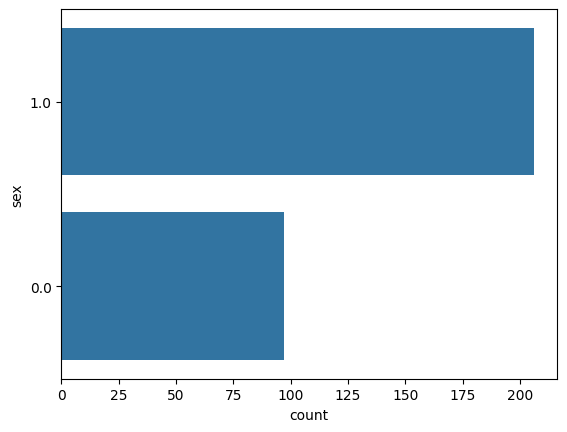

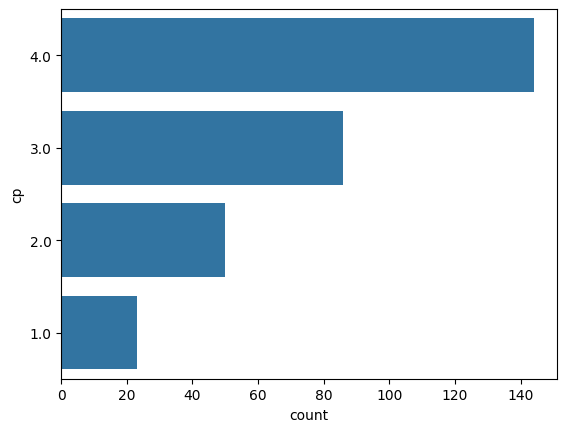

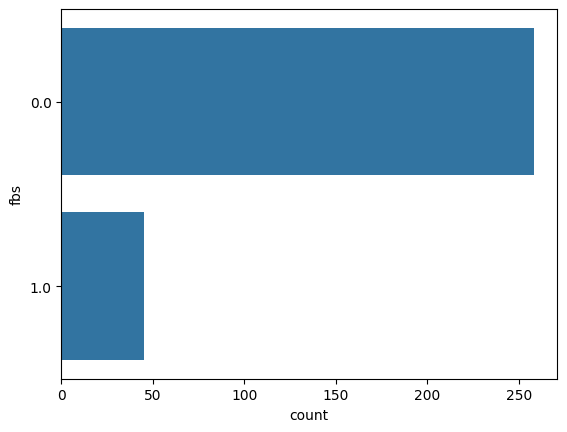

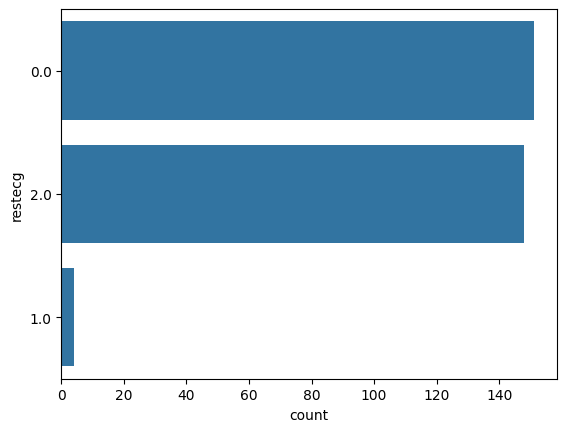

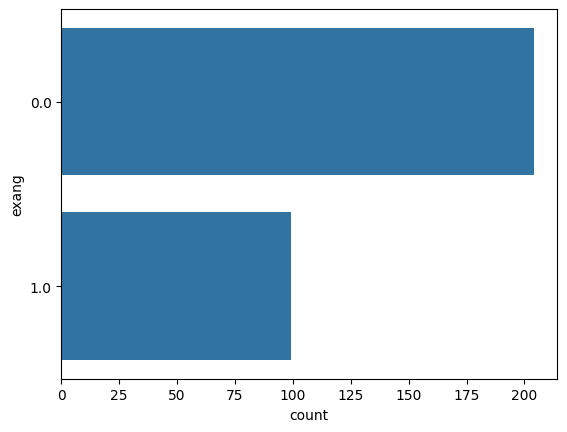

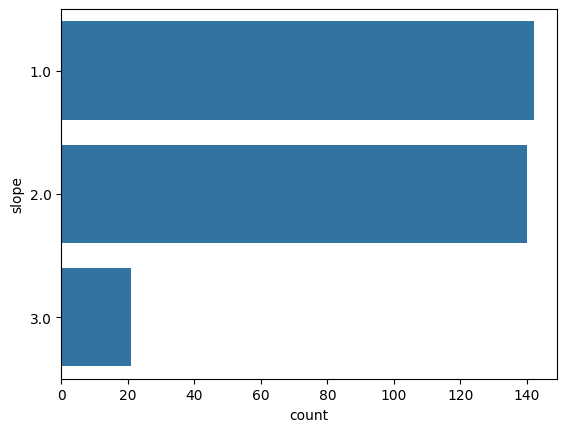

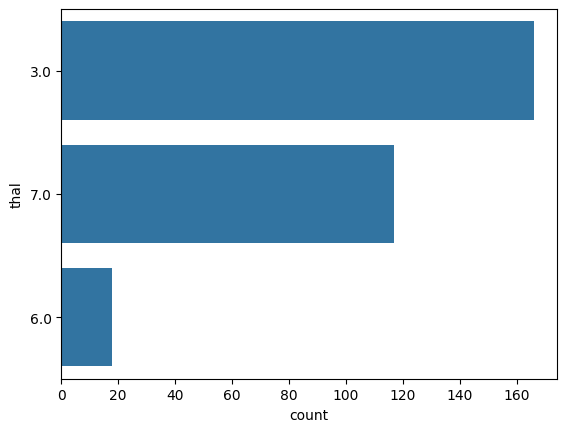

In [105]:
for cat in df.select_dtypes(include=['object']).columns:
    plt.figure()
    sns.countplot(data=df, y=cat, order=df[cat].value_counts().index)
    plt.show()

# Variables numéricas:

`a`. Identifiquen variables que sean (aproximadamente) normales y otras que tengan una distribución diferente.

Empezamos generando el historiograma, asintosis y kurtosis para verificar normalidad de las variables

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'trestbps'}>,
        <Axes: title={'center': 'chol'}>],
       [<Axes: title={'center': 'thalach'}>,
        <Axes: title={'center': 'oldpeak'}>,
        <Axes: title={'center': 'ca'}>],
       [<Axes: title={'center': 'target'}>, <Axes: >, <Axes: >]],
      dtype=object)

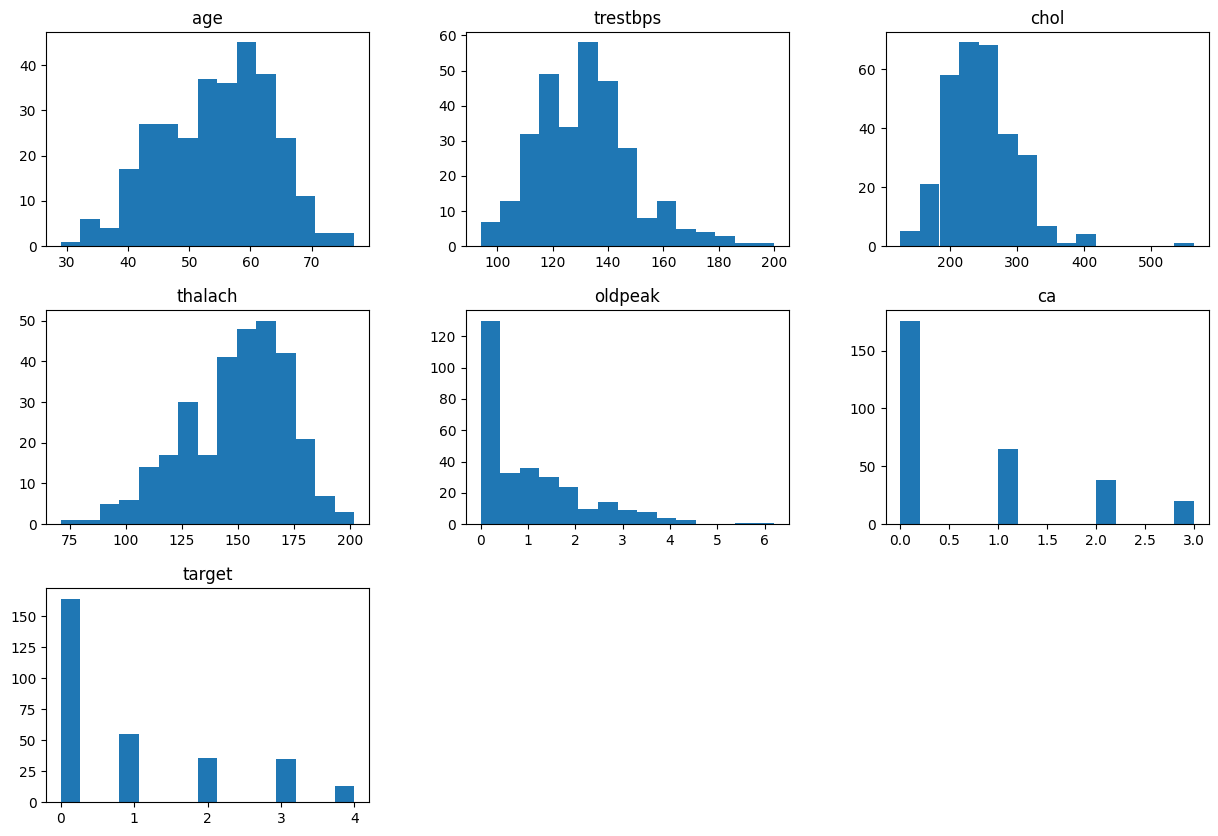

In [106]:
df.select_dtypes('number').hist(bins=15, figsize=(15, 10), grid=False,layout=(3, 3))

Obtencion de asimetria

In [107]:
for num in df.select_dtypes(include=['number']).columns:
    print(f"Asimetria de {num}: {df[num].skew():.3f} \n")

Asimetria de age: -0.209 

Asimetria de trestbps: 0.706 

Asimetria de chol: 1.136 

Asimetria de thalach: -0.537 

Asimetria de oldpeak: 1.270 

Asimetria de ca: 1.189 

Asimetria de target: 1.058 



Obtencion de kurtosis

In [108]:
for num in df.select_dtypes(include=['number']).columns:
    print(f"curtosisde {num}: {df[num].kurt():.3f} \n")

curtosisde age: -0.523 

curtosisde trestbps: 0.880 

curtosisde chol: 4.492 

curtosisde thalach: -0.054 

curtosisde oldpeak: 1.576 

curtosisde ca: 0.259 

curtosisde target: -0.139 



# Asimetria 

* age: distribucion casi simetrica con una cola muy leve a la izquierda 

* thalach: distribucion minimamente sesgada con una cola a la izquierda 

* Todas las demas variables tiene una asimetria muy alta


# Kurtosis 

* thalach y age : Tiende a una distribucion normal, sus colas son casi iguales 

* trestbps: Esta dentro de la zona normal, sin embargo, tiene una cola mas pesada a la derecha 

* Las otras varibles no tienden a ser normales 

Busqueda de Outlayers

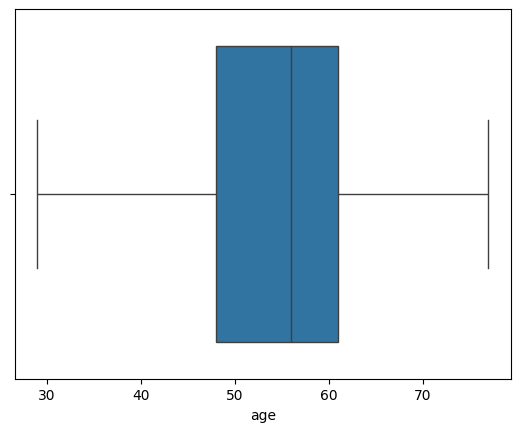

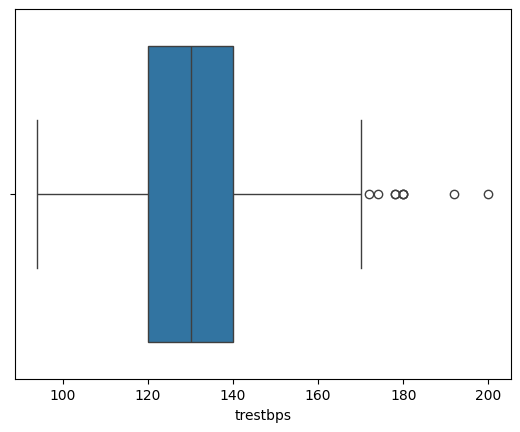

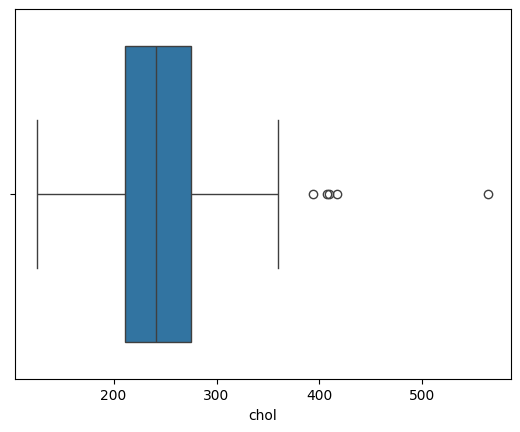

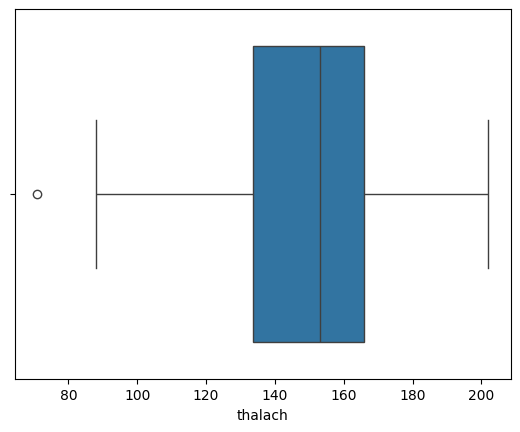

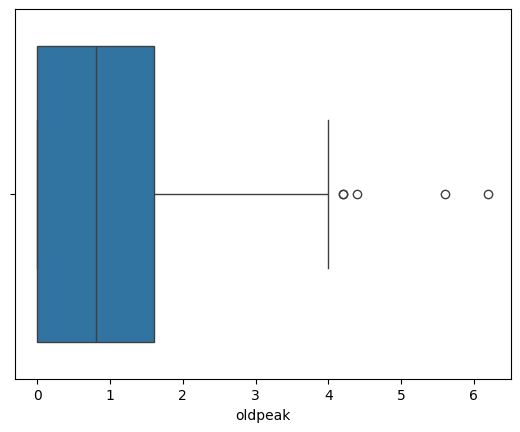

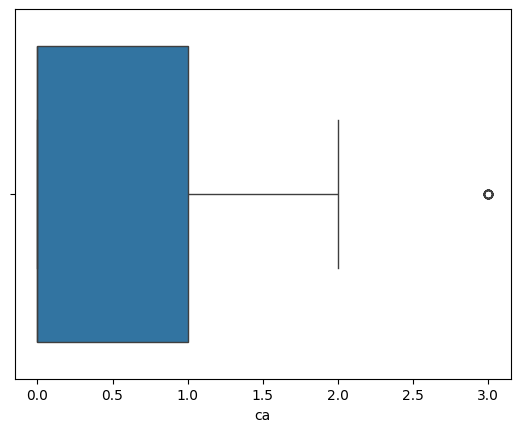

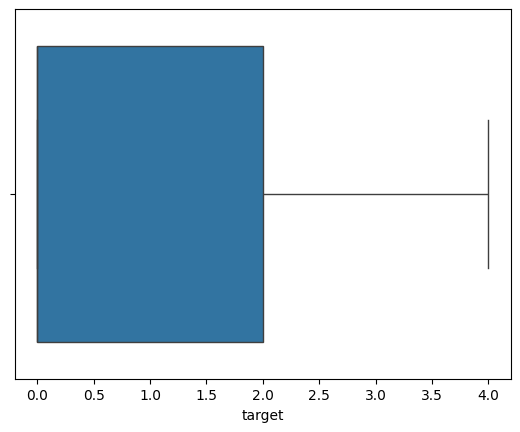

In [109]:
for num in df.select_dtypes(include=['number']).columns:
    plt.figure()
    sns.boxplot(data=df, x=num)
    plt.show()

Las varibles a las que se le identificaron Outlayers: 

* trestbps

* chol

* oldpeak


Estrategias para eliminar outlayers segun la variable

* trestbps le aplicaremos zscore ya que tiende a distribuirse medianamente normal 

* oldpeak y chol se le aplicara rango intercusrtil por que cuando se intento con eliminacion de persentiles se eliminaron muchos datos

In [110]:
print("numero de registros:", df.shape[0])

numero de registros: 303


In [111]:
df["zscore"] = (df["trestbps"] - df["trestbps"].mean()) / df["trestbps"].std()
df= df[(df["zscore"]<3) & (df["zscore"]>-3)]
print("numero de registros:", df.shape[0])

numero de registros: 301


In [112]:
Q1 = df["oldpeak"].quantile(0.25)
Q3 = df["oldpeak"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df["oldpeak"] < upper_bound) & (df["oldpeak"] > lower_bound)]
print("numero de registros:", df.shape[0])

numero de registros: 294


In [113]:
Q1 = df["chol"].quantile(0.25)
Q3 = df["chol"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df["chol"] < upper_bound) & (df["chol"] > lower_bound)]
print("numero de registros:", df.shape[0])

numero de registros: 290


array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'trestbps'}>,
        <Axes: title={'center': 'chol'}>],
       [<Axes: title={'center': 'thalach'}>,
        <Axes: title={'center': 'oldpeak'}>,
        <Axes: title={'center': 'ca'}>],
       [<Axes: title={'center': 'target'}>,
        <Axes: title={'center': 'zscore'}>, <Axes: >]], dtype=object)

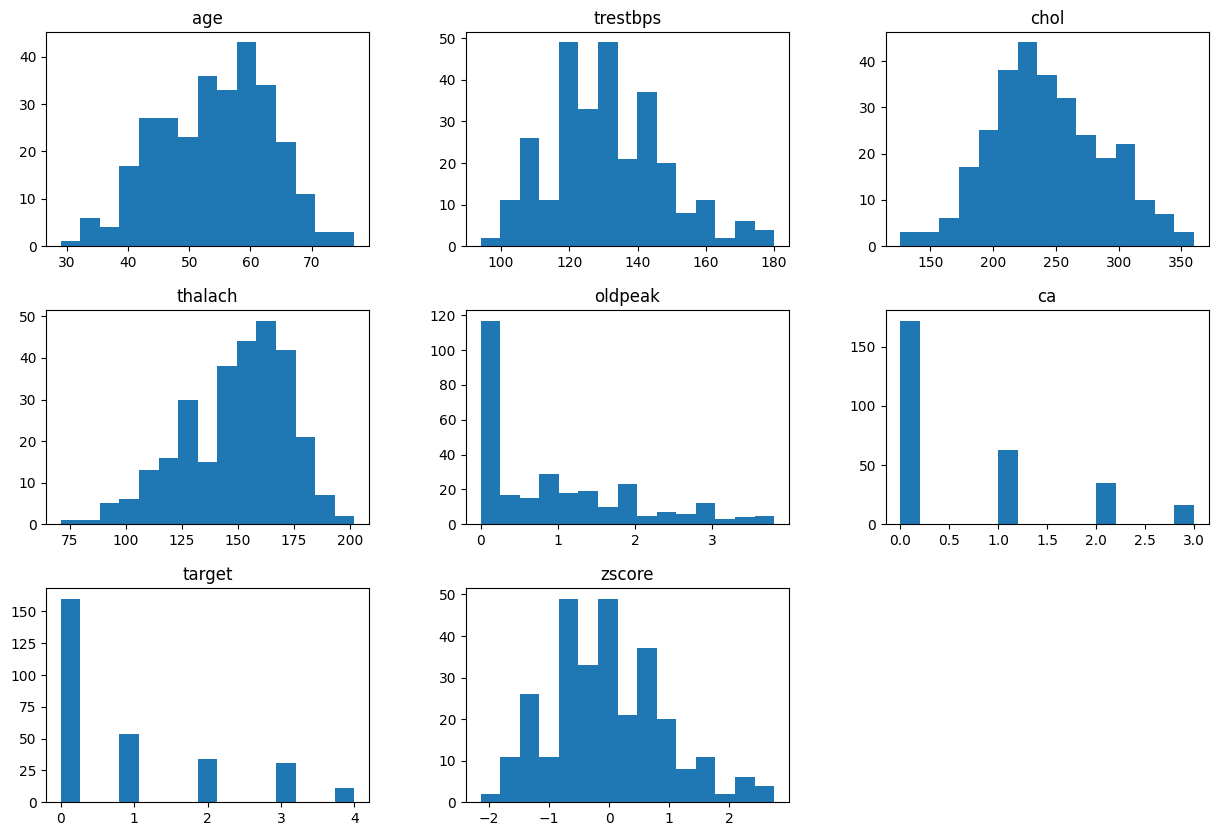

In [114]:
df.select_dtypes('number').hist(bins=15, figsize=(15, 10), grid=False,layout=(3, 3))

<Figure size 640x480 with 0 Axes>

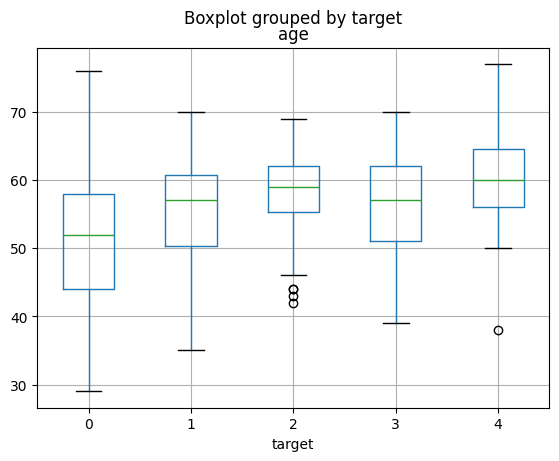

<Figure size 640x480 with 0 Axes>

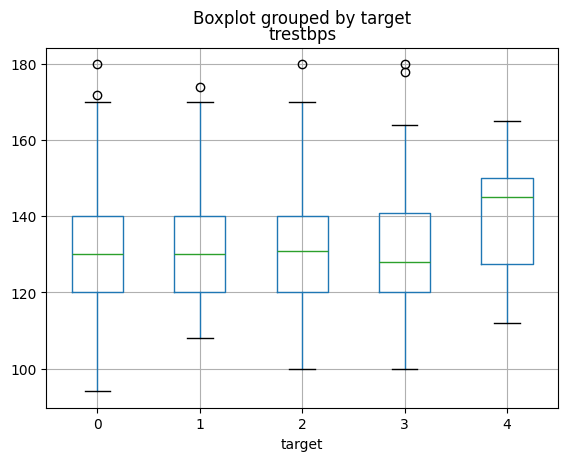

<Figure size 640x480 with 0 Axes>

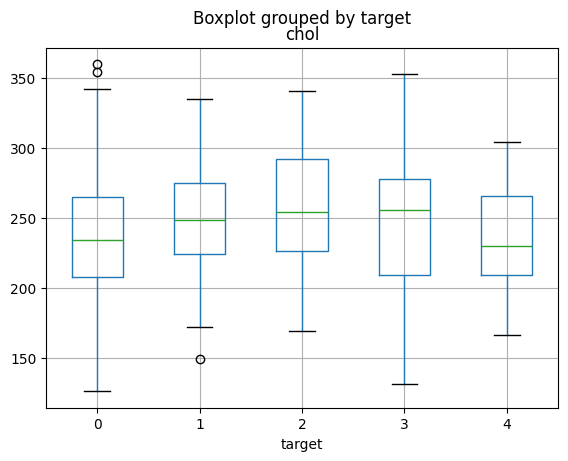

<Figure size 640x480 with 0 Axes>

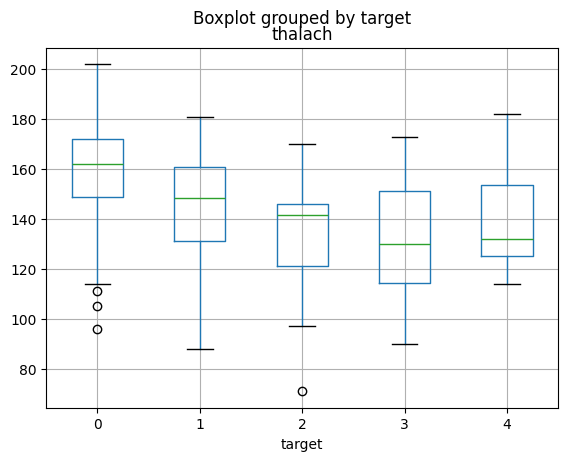

<Figure size 640x480 with 0 Axes>

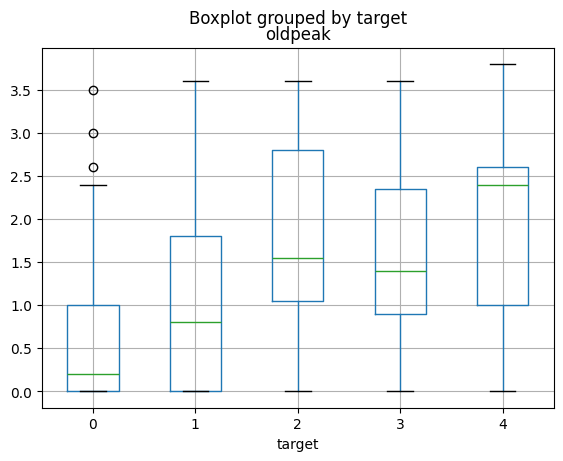

<Figure size 640x480 with 0 Axes>

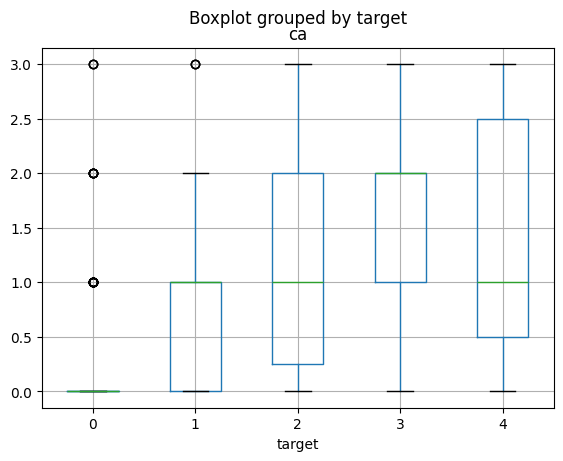

<Figure size 640x480 with 0 Axes>

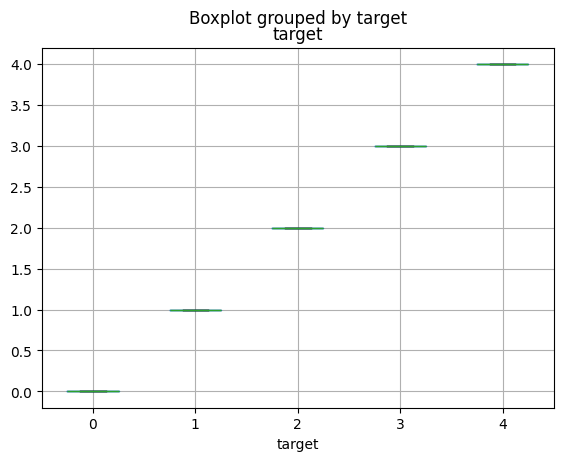

<Figure size 640x480 with 0 Axes>

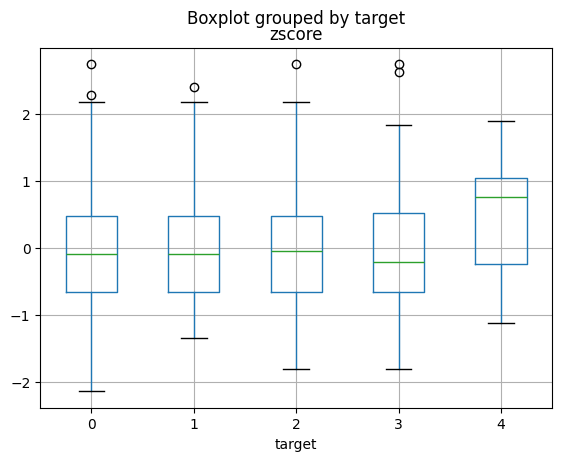

In [115]:
num_vars = df.select_dtypes(include=['number']).columns
for num in num_vars:
    plt.figure()
    df.boxplot(by="target", column=num)
    plt.title(num)
    plt.show()

# Analisis 

Se decide descartar la varible trestbps (la presión en reposo) los motivos son:

*  no ayuda mucho a predecir el target

* El modelo difícilmente encontrará patrones fuertes aquí debido a que los rangos son casi iguales en los valores que toma target

* las medianas son muy similares 

Decidimos manter chol(colesterol) ya que esta variablke si es un factor importante a la hora de predecir una enfermedad cardiaca 

In [117]:
df = df.drop(columns=["zscore", "trestbps"])


# Matriz de correlacion 

<Axes: >

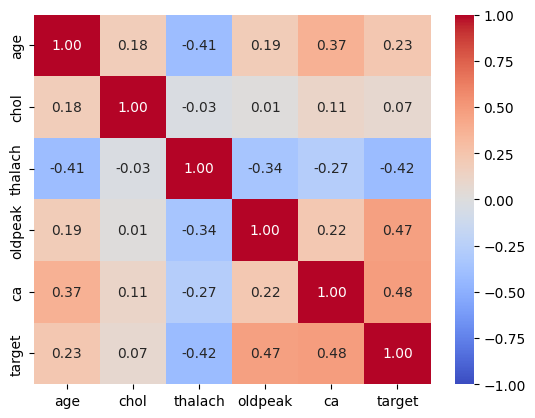

In [122]:
corr = df.select_dtypes('number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)

De esta matriz podemos concluir que: 

* Las variables ca, oldpeak, thalach influyen de manera significa a la variable predictoria target

* Las variables chol y age no ayudan a predir la variable predictoria target, por lo tanto podriamos eliminar chol 

In [123]:
df.drop(columns=["chol"], inplace=True)

In [124]:
df.info()

<class 'pandas.DataFrame'>
Index: 290 entries, 0 to 302
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   age      290 non-null    float64
 1   sex      290 non-null    str    
 2   cp       290 non-null    str    
 3   restecg  290 non-null    str    
 4   thalach  290 non-null    float64
 5   exang    290 non-null    str    
 6   oldpeak  290 non-null    float64
 7   slope    290 non-null    str    
 8   ca       286 non-null    float64
 9   thal     288 non-null    str    
 10  target   290 non-null    int64  
dtypes: float64(4), int64(1), str(6)
memory usage: 27.2 KB


# Variables categoricas:  

In [119]:
var_categoricas = df.select_dtypes(include=['object']).columns
for var in var_categoricas:
    print(f"Variable: {var}: {df[var].unique()} \n")

Variable: sex: <StringArray>
['1.0', '0.0']
Length: 2, dtype: str 

Variable: cp: <StringArray>
['1.0', '4.0', '3.0', '2.0']
Length: 4, dtype: str 

Variable: fbs: <StringArray>
['1.0', '0.0']
Length: 2, dtype: str 

Variable: restecg: <StringArray>
['2.0', '0.0', '1.0']
Length: 3, dtype: str 

Variable: exang: <StringArray>
['0.0', '1.0']
Length: 2, dtype: str 

Variable: slope: <StringArray>
['3.0', '2.0', '1.0']
Length: 3, dtype: str 

Variable: thal: <StringArray>
['6.0', '3.0', '7.0', nan]
Length: 4, dtype: str 



/tmp/ipykernel_8335/587241948.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  var_categoricas = df.select_dtypes(include=['object']).columns


Se puede concluir que ninguna variable es de alta cardinalidad y tiene pocas categorias definidas 

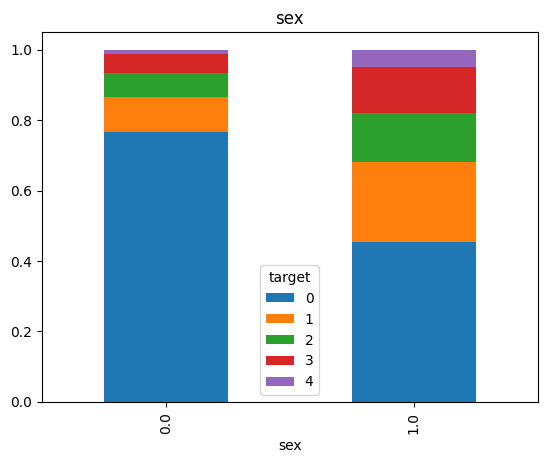

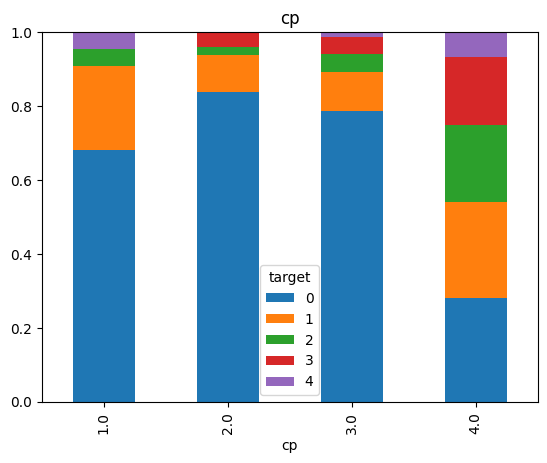

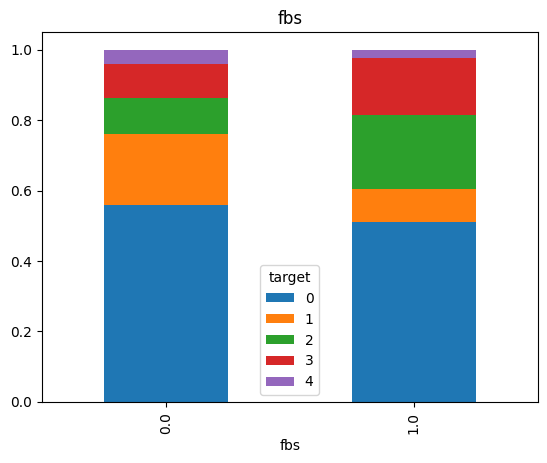

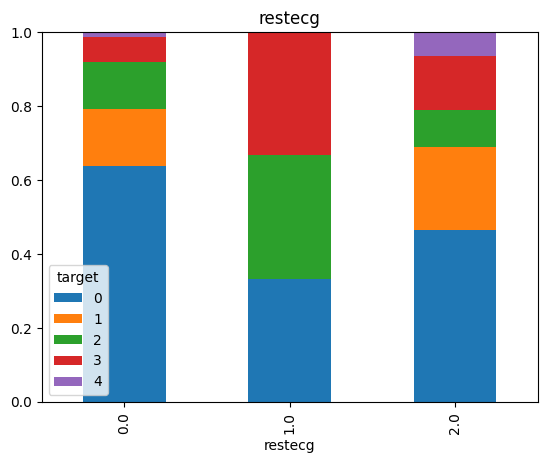

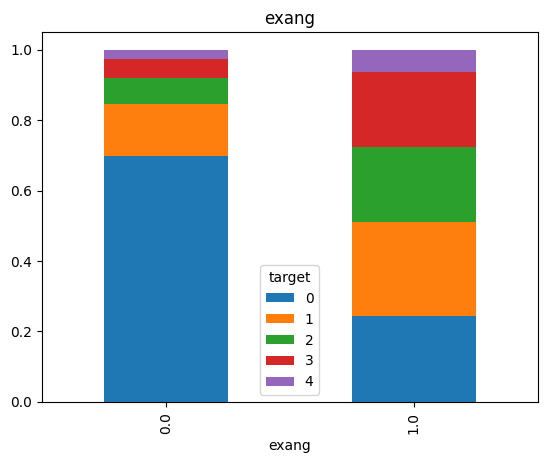

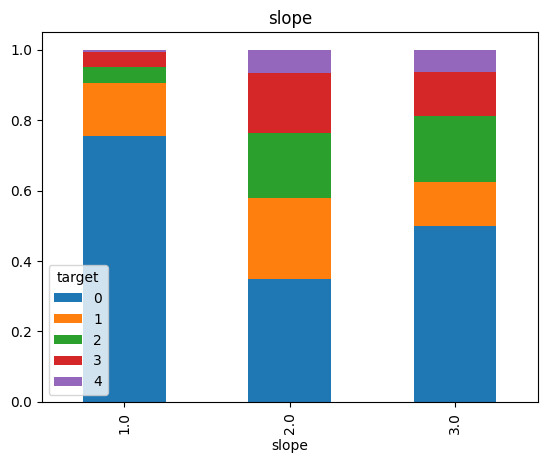

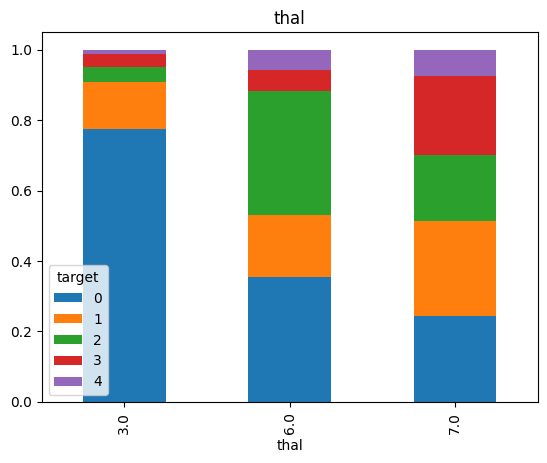

In [120]:
import matplotlib.pyplot as plt

#analsis bivairado entre variables categoricas y variable objetivo: churn label
for var in var_categoricas:
    tabla = pd.crosstab(df[var], df['target'], normalize='index')
    tabla.plot(kind='bar', stacked=True)
    plt.title(var)
    plt.show()

# Analisis 

Se decide eliminar la variable fbs(cantidad de glusemis en ayunas como indicador de diabetis) porque para predecir si una persona padece enfermedad cardiovascular (target) no influye segun la muestra la cantidad de glucosa.

In [121]:
df = df.drop(columns=["fbs"])

# Preprocesamiento de los datos